In [75]:
# --- Cell 1: Imports ---

import seaborn as sns
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_squared_error, r2_score

import pickle

In [76]:
# --- Cell 2: Fetch data ---

btc = yf.Ticker('BTC-USD')
prices1 = btc.history(period='5y')

prices1.drop(
    columns=['Open', 'High', 'Low', 'Dividends', 'Stock Splits'],
    axis=1,
    inplace=True
)


eth = yf.Ticker('ETH-USD')
prices2 = eth.history(period='5y')

prices2.drop(
    columns=['Open', 'High', 'Low', 'Dividends', 'Stock Splits'],
    axis=1,
    inplace=True
)


usdt = yf.Ticker('USDT-USD')
prices3 = usdt.history(period='5y')

prices3.drop(
    columns=['Open', 'High', 'Low', 'Dividends', 'Stock Splits'],
    axis=1,
    inplace=True
)


bnb = yf.Ticker('BNB-USD')
prices4 = bnb.history(period='5y')

prices4.drop(
    columns=['Open', 'High', 'Low', 'Dividends', 'Stock Splits'],
    axis=1,
    inplace=True
)

In [77]:
# --- Cell 3: Join datasets ---

p1 = prices1.join(
    prices2,
    lsuffix=' (BTC)',
    rsuffix=' (ETH)'
)

p2 = prices3.join(
    prices4,
    lsuffix=' (USDT)',
    rsuffix=' (BNB)'
)

data = p1.join(
    p2,
    lsuffix='_',
    rsuffix='_'
)

In [79]:
data.head()

,Close (BTC),Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,,
2021-09-22 00:00:00+00:00,43574.507812,38139709246,3077.867920,23742102645,1.000040,80708278656,379.440338,1678913732
2021-09-23 00:00:00+00:00,44895.097656,34244064430,3155.523682,18516291047,1.000508,71255677560,383.820404,1576382603
2021-09-24 00:00:00+00:00,42839.750000,42839345714,2931.669189,25595422789,1.000820,93076113024,355.316284,2081157733
2021-09-25 00:00:00+00:00,42716.593750,31604717236,2925.565674,18932786754,1.000989,66583739947,349.880096,1388464569
2021-09-26 00:00:00+00:00,43208.539062,30661222077,3062.265381,21172766310,1.000725,78196884599,344.181763,1958526741


In [80]:
# --- Cell 4: Basic inspection ---

print("First 5 rows:")
display(data.head())

print("\nLast 5 rows:")
display(data.tail())

print("\nShape:")
print(data.shape)

print("\nInformation:")
data.info()

print("\nMissing values:")
print(data.isna().sum())

print("\nStatistical description:")
display(data.describe())

First 5 rows:


,Close (BTC),Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,,
2021-09-22 00:00:00+00:00,43574.507812,38139709246,3077.867920,23742102645,1.000040,80708278656,379.440338,1678913732
2021-09-23 00:00:00+00:00,44895.097656,34244064430,3155.523682,18516291047,1.000508,71255677560,383.820404,1576382603
2021-09-24 00:00:00+00:00,42839.750000,42839345714,2931.669189,25595422789,1.000820,93076113024,355.316284,2081157733
2021-09-25 00:00:00+00:00,42716.593750,31604717236,2925.565674,18932786754,1.000989,66583739947,349.880096,1388464569
2021-09-26 00:00:00+00:00,43208.539062,30661222077,3062.265381,21172766310,1.000725,78196884599,344.181763,1958526741



Last 5 rows:


,Close (BTC),Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,,
2026-09-18 00:00:00+00:00,80901.460938,40378562386,2611.347168,22570923683,0.999659,97509978528,761.016418,2183916470
2026-09-19 00:00:00+00:00,81233.679688,20505634866,2631.962646,10007872025,0.999637,59790373738,762.044373,1537324950
2026-09-20 00:00:00+00:00,81142.609375,21259753701,2642.997559,10759191352,0.999754,58834219902,772.348145,1590467764
2026-09-21 00:00:00+00:00,86602.914062,57676223471,2776.468262,26510460373,0.999869,121758942129,798.890137,2695025332
2026-09-22 00:00:00+00:00,86405.140625,41381068800,2743.669922,16961236992,0.999950,95262695424,789.099976,2084573952



Shape:
(1827, 8)

Information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1827 entries, 2021-09-22 00:00:00+00:00 to 2026-09-22 00:00:00+00:00
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Close (BTC)    1827 non-null   float64
 1   Volume (BTC)   1827 non-null   int64  
 2   Close (ETH)    1827 non-null   float64
 3   Volume (ETH)   1827 non-null   int64  
 4   Close (USDT)   1827 non-null   float64
 5   Volume (USDT)  1827 non-null   int64  
 6   Close (BNB)    1827 non-null   float64
 7   Volume (BNB)   1827 non-null   int64  
dtypes: float64(4), int64(4)
memory usage: 128.5 KB

Missing values:
Close (BTC)      0
Volume (BTC)     0
Close (ETH)      0
Volume (ETH)     0
Close (USDT)     0
Volume (USDT)    0
Close (BNB)      0
Volume (BNB)     0
dtype: int64

Statistical description:


,Close (BTC),Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
count,1827.000000,1.827000e+03,1827.000000,1.827000e+03,1827.000000,1.827000e+03,1827.000000,1.827000e+03
mean,58497.969008,3.471041e+10,2517.002673,1.765681e+10,0.999983,6.774523e+10,506.141064,1.633873e+09
std,29755.266686,2.054969e+10,884.120277,1.182043e+10,0.000659,4.219478e+10,218.006556,1.091570e+09
min,15787.284180,5.331173e+09,993.636780,2.081626e+09,0.995872,9.989859e+09,197.042999,2.038465e+08
25%,29412.204102,2.051595e+10,1810.192871,9.503578e+09,0.999686,3.944689e+10,304.748932,9.030619e+08
50%,60320.136719,3.027666e+10,2372.201904,1.519706e+10,1.000070,5.845676e+10,547.326233,1.524500e+09
75%,80222.152344,4.262689e+10,3145.233765,2.183691e+10,1.000291,8.337169e+10,634.554077,2.023324e+09
max,124752.531250,1.817464e+11,4831.348633,9.773662e+10,1.007690,3.443980e+11,1310.214355,1.182039e+10


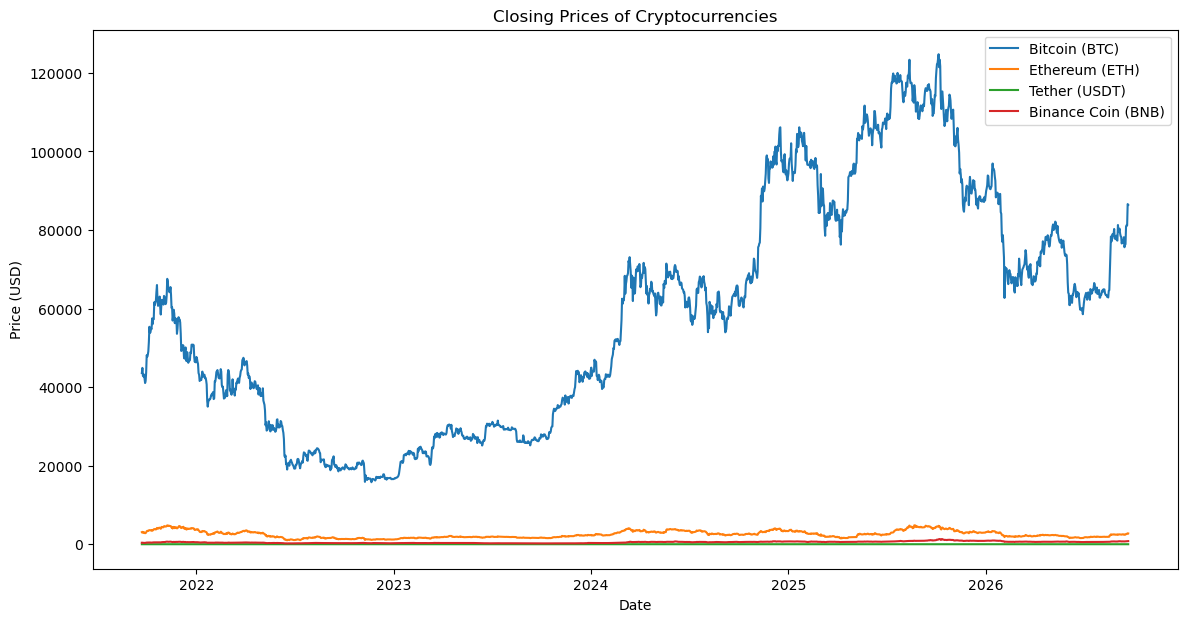

In [81]:
# --- EDA: Closing Prices ---

plt.figure(figsize=(14, 7))

plt.plot(
    data.index,
    data['Close (BTC)'],
    label='Bitcoin (BTC)'
)

plt.plot(
    data.index,
    data['Close (ETH)'],
    label='Ethereum (ETH)'
)

plt.plot(
    data.index,
    data['Close (USDT)'],
    label='Tether (USDT)'
)

plt.plot(
    data.index,
    data['Close (BNB)'],
    label='Binance Coin (BNB)'
)

plt.title('Closing Prices of Cryptocurrencies')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()

plt.show()

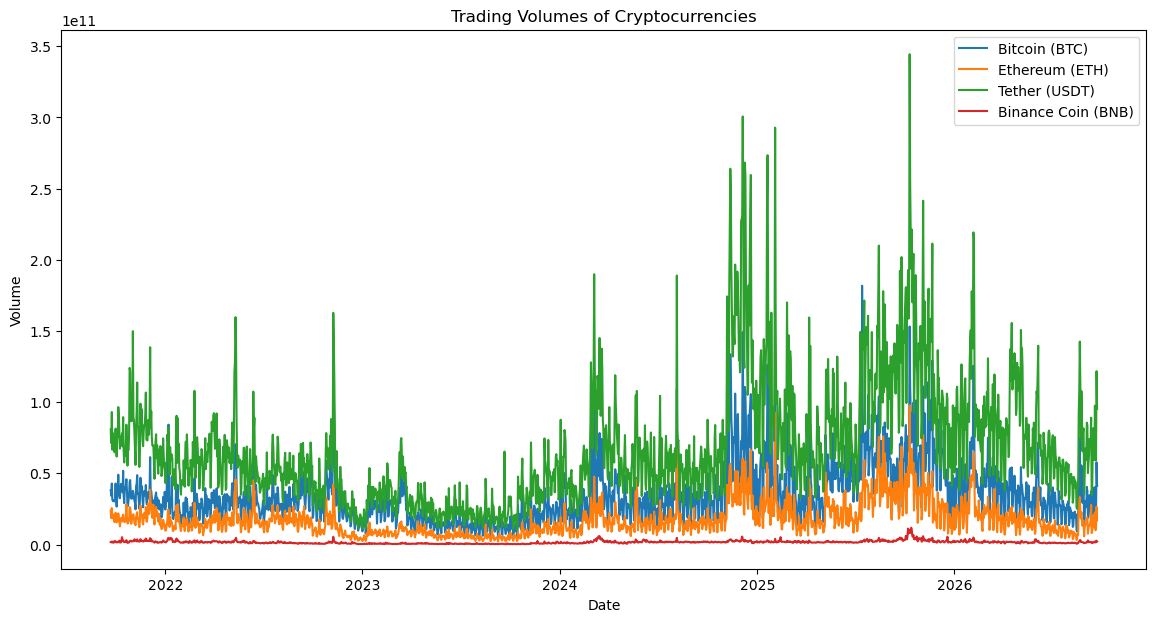

In [82]:
# --- EDA: Trading Volumes ---

plt.figure(figsize=(14, 7))

plt.plot(
    data.index,
    data['Volume (BTC)'],
    label='Bitcoin (BTC)'
)

plt.plot(
    data.index,
    data['Volume (ETH)'],
    label='Ethereum (ETH)'
)

plt.plot(
    data.index,
    data['Volume (USDT)'],
    label='Tether (USDT)'
)

plt.plot(
    data.index,
    data['Volume (BNB)'],
    label='Binance Coin (BNB)'
)

plt.title('Trading Volumes of Cryptocurrencies')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()

plt.show()

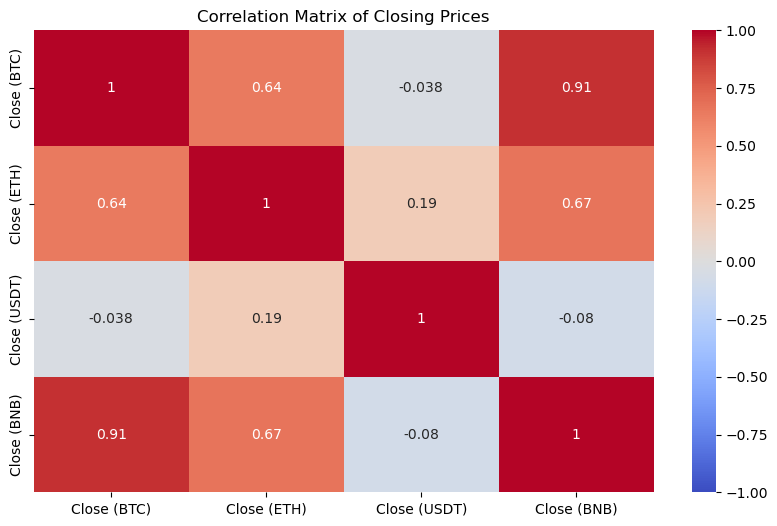

In [84]:
# --- EDA: Correlation Heatmap ---

corr_matrix = data[
    [
        'Close (BTC)',
        'Close (ETH)',
        'Close (USDT)',
        'Close (BNB)'
    ]
].corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title('Correlation Matrix of Closing Prices')

plt.show()

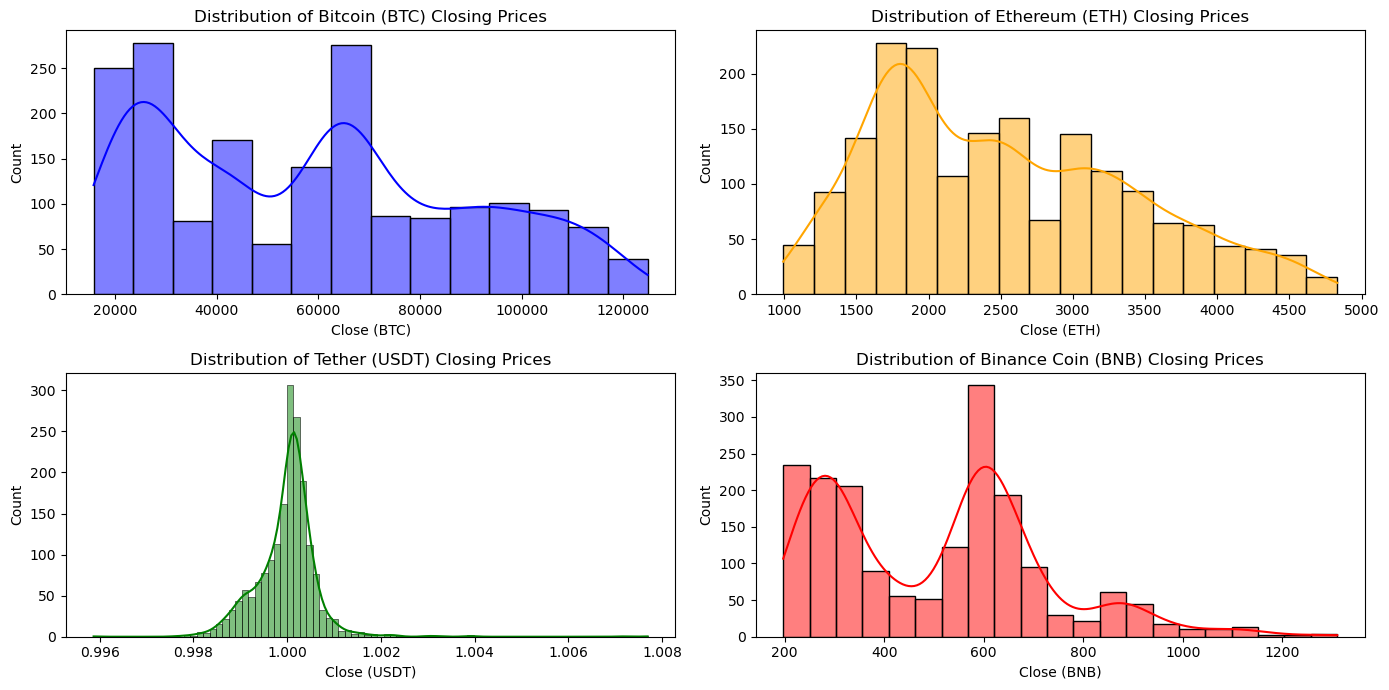

In [85]:
# --- EDA: Distributions ---

plt.figure(figsize=(14, 7))

plt.subplot(2, 2, 1)
sns.histplot(
    data['Close (BTC)'],
    kde=True,
    color='blue'
)
plt.title('Distribution of Bitcoin (BTC) Closing Prices')


plt.subplot(2, 2, 2)
sns.histplot(
    data['Close (ETH)'],
    kde=True,
    color='orange'
)
plt.title('Distribution of Ethereum (ETH) Closing Prices')


plt.subplot(2, 2, 3)
sns.histplot(
    data['Close (USDT)'],
    kde=True,
    color='green'
)
plt.title('Distribution of Tether (USDT) Closing Prices')


plt.subplot(2, 2, 4)
sns.histplot(
    data['Close (BNB)'],
    kde=True,
    color='red'
)
plt.title('Distribution of Binance Coin (BNB) Closing Prices')

plt.tight_layout()
plt.show()

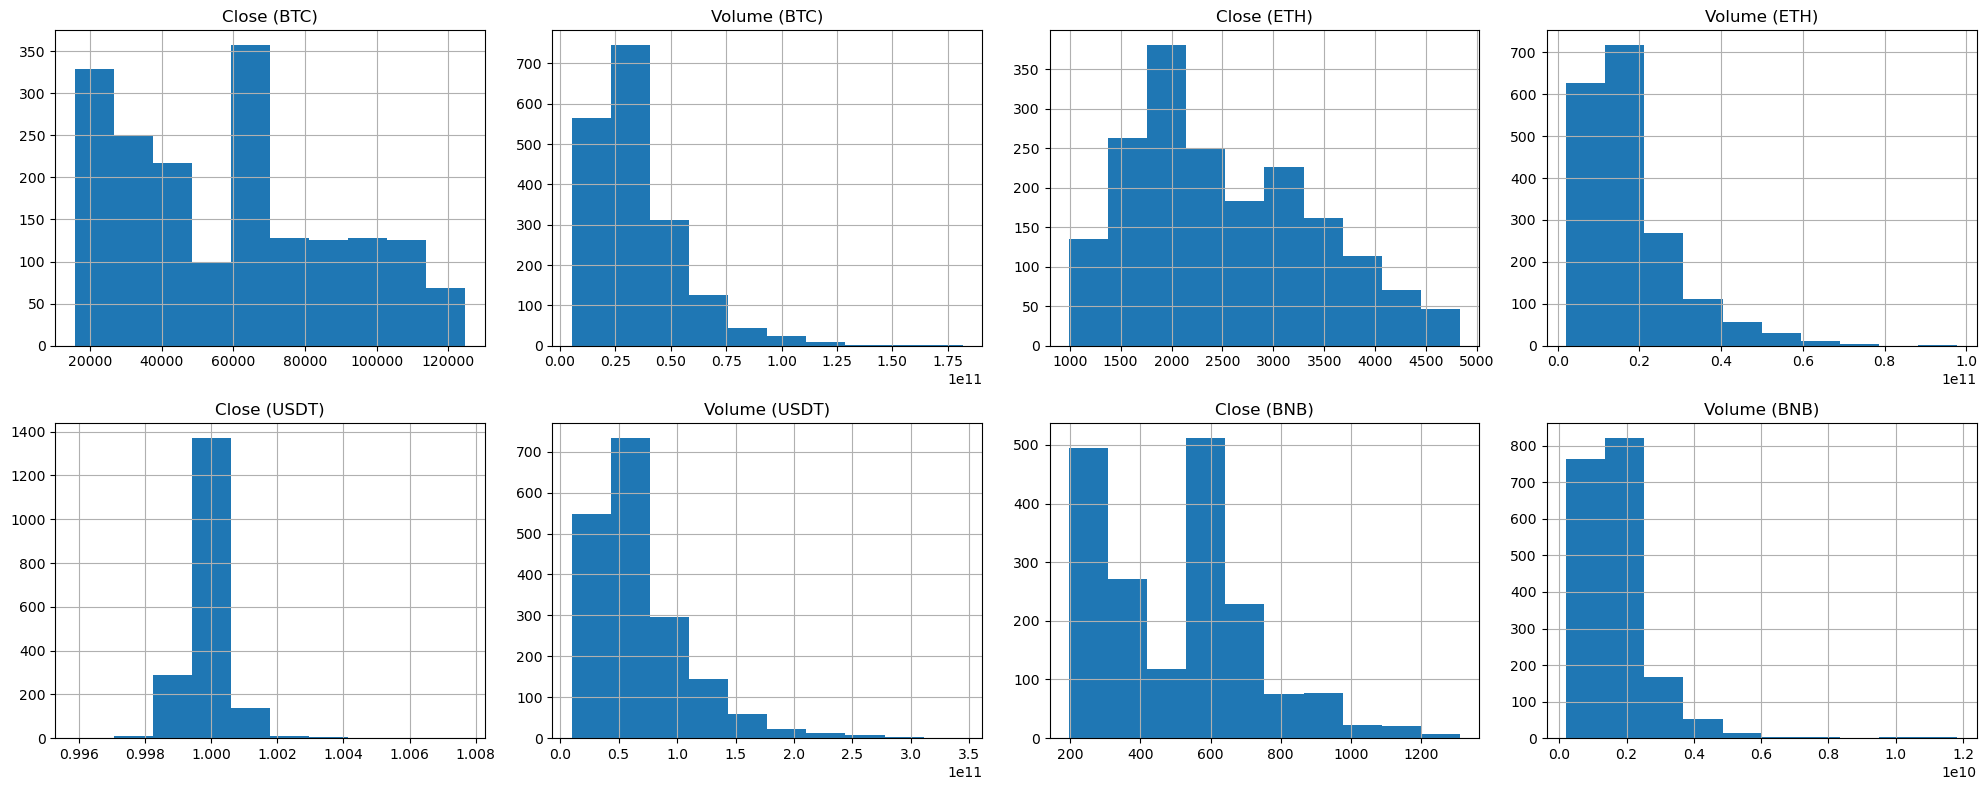

In [86]:
# --- Additional EDA ---

data.hist(
    figsize=(20, 8),
    layout=(2, 4)
)

plt.tight_layout()
plt.show()

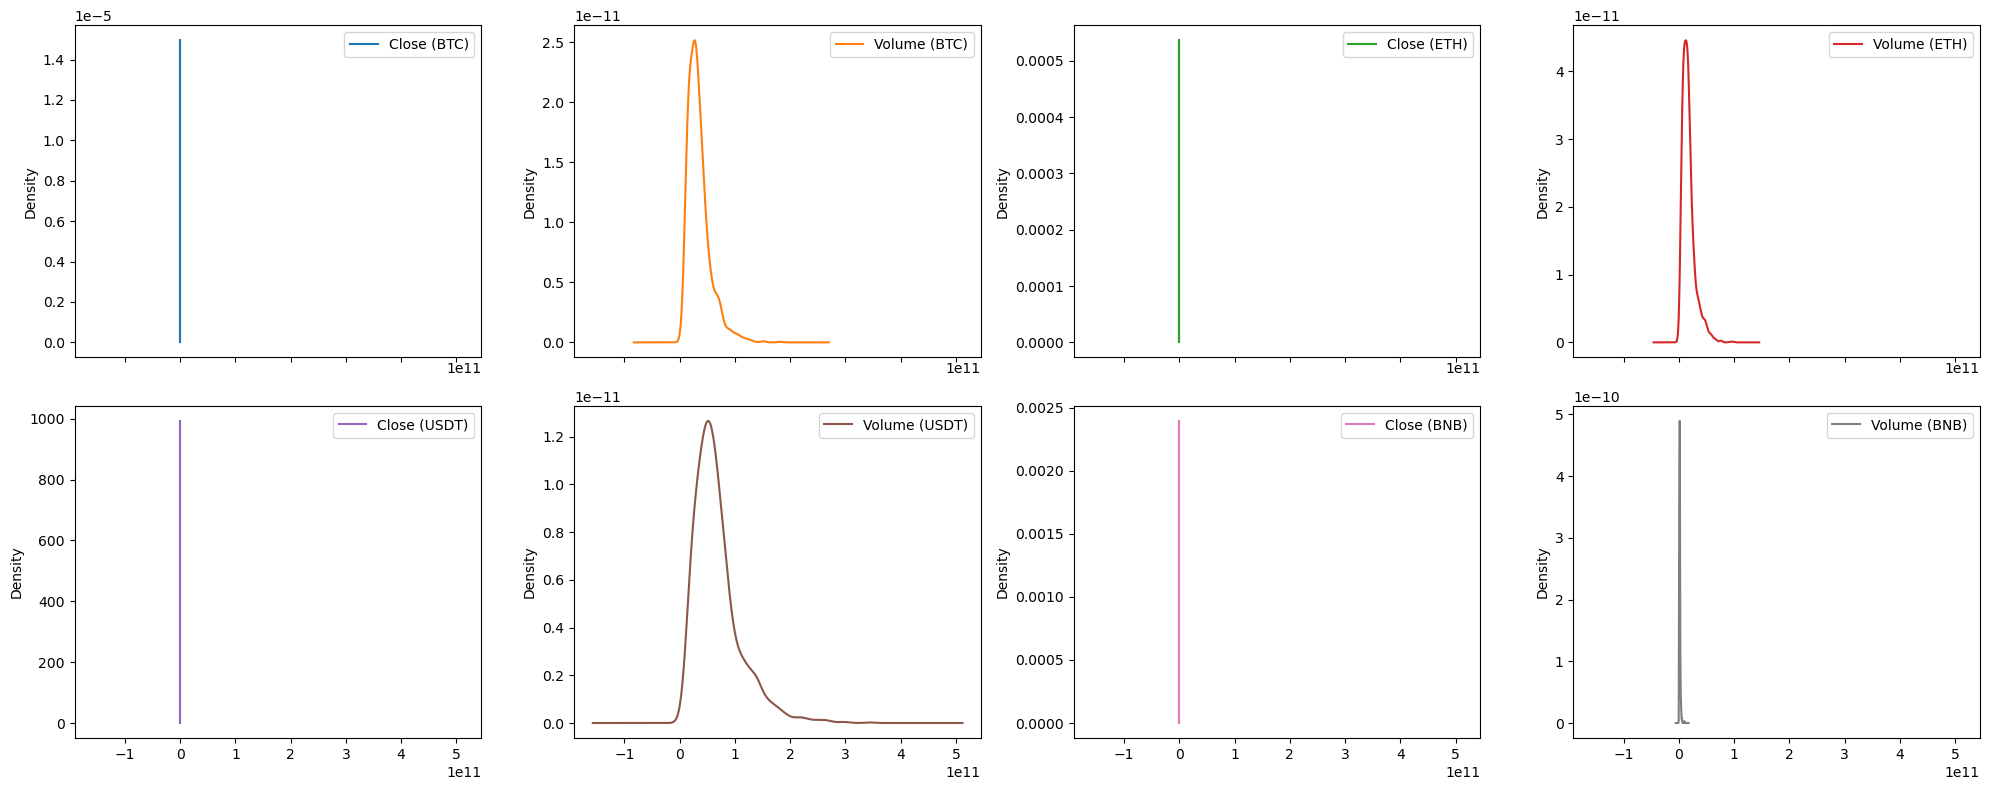

In [87]:
data.plot(
    kind='kde',
    subplots=True,
    layout=(2, 4),
    figsize=(20, 8)
)

plt.tight_layout()
plt.show()

In [88]:
# --- Data Pre-processing ---

X = data.drop(
    columns=['Close (BTC)'],
    axis=1
)

Y = data['Close (BTC)']

In [89]:
# --- Train/Test Split ---

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=0
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'Y_train shape: {Y_train.shape}')
print(f'Y_test shape: {Y_test.shape}')

X_train shape: (1461, 7)
X_test shape: (366, 7)
Y_train shape: (1461,)
Y_test shape: (366,)


In [90]:
# --- Scaling ---

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("X_train after scaling:")
print(X_train[:5])

print("\nX_test after scaling:")
print(X_test[:5])

X_train after scaling:
[[0.17004636 0.03492178 0.20609333 0.26205919 0.13640102 0.01606
  0.09722414]
 [0.10795396 0.427978   0.11800378 0.3426152  0.14118296 0.15149609
  0.11398519]
 [0.04489356 0.23644032 0.03430886 0.36223975 0.03440684 0.1029864
  0.01620038]
 [0.27940361 0.18497228 0.14717638 0.62405181 0.19374108 0.1009079
  0.05701589]
 [0.22620316 0.27566855 0.17720026 0.36528607 0.22210105 0.40823484
  0.12161574]]

X_test after scaling:
[[0.09974551 0.08989705 0.14633931 0.32678845 0.09628769 0.04564031
  0.07291458]
 [0.11945621 0.14669352 0.06375672 0.36030302 0.07412531 0.09303989
  0.05885421]
 [0.08862342 0.05212582 0.10883488 0.27246409 0.08763869 0.03288894
  0.05486046]
 [0.04769215 0.2787206  0.06244513 0.36715219 0.060734   0.03144547
  0.03464763]
 [0.10519103 0.63277628 0.1039435  0.40057093 0.17243578 0.19219222
  0.11333781]]


In [91]:
# --- Compare 10 Regression Models ---

models = {

    'Linear Regression':
        LinearRegression(),

    'Ridge Regression':
        Ridge(alpha=1.0),

    'Lasso Regression':
        Lasso(alpha=1.0),

    'ElasticNet Regression':
        ElasticNet(
            alpha=1.0,
            l1_ratio=0.5
        ),

    'Support Vector Regression (SVR)':
        SVR(kernel='rbf'),

    'Decision Tree Regression':
        DecisionTreeRegressor(
            random_state=0
        ),

    'Random Forest Regression':
        RandomForestRegressor(
            n_estimators=100,
            random_state=0
        ),

    'Gradient Boosting Regression':
        GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.1,
            random_state=0
        ),

    'K-Nearest Neighbors Regression':
        KNeighborsRegressor(
            n_neighbors=5
        ),

    'Neural Network Regression (MLP)':
        MLPRegressor(
            hidden_layer_sizes=(100, 50),
            activation='relu',
            solver='adam',
            random_state=0,
            max_iter=1000
        )
}

In [92]:
# --- Train and Evaluate Models ---

results = {
    'Model': [],
    'MSE': [],
    'R-squared': []
}

for name, model in models.items():

    print(f"----- {name} -----")

    # Train
    model.fit(
        X_train,
        Y_train
    )

    # Predict
    Y_pred = model.predict(
        X_test
    )

    # Metrics
    mse = mean_squared_error(
        Y_test,
        Y_pred
    )

    r2 = r2_score(
        Y_test,
        Y_pred
    )

    # Store results
    results['Model'].append(name)
    results['MSE'].append(mse)
    results['R-squared'].append(r2)

    print(
        f"Mean Squared Error (MSE): {mse}"
    )

    print(
        f"R-squared: {r2}"
    )

    print()

----- Linear Regression -----
Mean Squared Error (MSE): 126911988.59948914
R-squared: 0.8544875575234706

----- Ridge Regression -----
Mean Squared Error (MSE): 129310423.94482517
R-squared: 0.8517376030938439

----- Lasso Regression -----
Mean Squared Error (MSE): 126954613.74493419
R-squared: 0.8544386851585106

----- ElasticNet Regression -----
Mean Squared Error (MSE): 680668078.4893193
R-squared: 0.21957195919956163

----- Support Vector Regression (SVR) -----
Mean Squared Error (MSE): 864333886.148878
R-squared: 0.008987753823124778

----- Decision Tree Regression -----
Mean Squared Error (MSE): 50424859.48850373
R-squared: 0.942184780597335

----- Random Forest Regression -----
Mean Squared Error (MSE): 28985141.071342885
R-squared: 0.9667667434782056

----- Gradient Boosting Regression -----
Mean Squared Error (MSE): 45744422.88922779
R-squared: 0.9475511905711516

----- K-Nearest Neighbors Regression -----
Mean Squared Error (MSE): 23494043.51122015
R-squared: 0.97306262637049

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [93]:
results_df = pd.DataFrame(results)

print(results_df)

                             Model           MSE  R-squared
0                Linear Regression  1.269120e+08   0.854488
1                 Ridge Regression  1.293104e+08   0.851738
2                 Lasso Regression  1.269546e+08   0.854439
3            ElasticNet Regression  6.806681e+08   0.219572
4  Support Vector Regression (SVR)  8.643339e+08   0.008988
5         Decision Tree Regression  5.042486e+07   0.942185
6         Random Forest Regression  2.898514e+07   0.966767
7     Gradient Boosting Regression  4.574442e+07   0.947551
8   K-Nearest Neighbors Regression  2.349404e+07   0.973063
9  Neural Network Regression (MLP)  1.539480e+08   0.823489


In [94]:
# --- Final Random Forest Model ---

model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=0
)

model_rf.fit(
    X_train,
    Y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [95]:
# --- Prediction ---

Y_pred = model_rf.predict(X_test)

print("First 10 Actual Values:")
print(Y_test.iloc[:10].values)

print("\nFirst 10 Predicted Values:")
print(Y_pred[:10])

First 10 Actual Values:
[ 20779.34375     22636.46875     20735.47851562  37479.12109375
  62029.84765625  19419.50585938  29445.95703125  41796.26953125
  59119.4765625  113320.0859375 ]

First 10 Predicted Values:
[ 20923.23396484  21539.481875    20593.16935547  37504.32458984
  55135.68832031  19062.23191406  29738.8584375   42246.89300781
  58699.42285156 107582.343125  ]


In [96]:
# --- Final Model Evaluation ---

mse = mean_squared_error(
    Y_test,
    Y_pred
)

r2 = r2_score(
    Y_test,
    Y_pred
)

print("Random Forest Regression Results")
print("----------------------------------")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared: {r2}")

Random Forest Regression Results
----------------------------------
Mean Squared Error (MSE): 28985141.071342885
R-squared: 0.9667667434782056


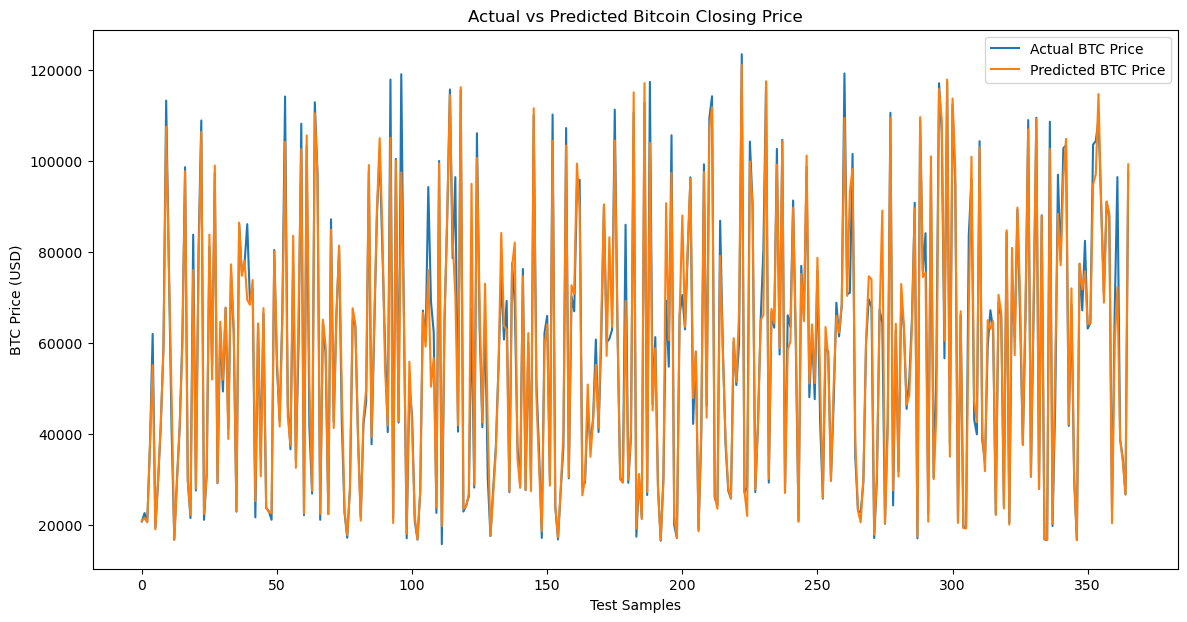

In [97]:
plt.figure(figsize=(14, 7))

plt.plot(
    Y_test.values,
    label="Actual BTC Price"
)

plt.plot(
    Y_pred,
    label="Predicted BTC Price"
)

plt.title("Actual vs Predicted Bitcoin Closing Price")
plt.xlabel("Test Samples")
plt.ylabel("BTC Price (USD)")
plt.legend()

plt.show()

In [98]:
import pickle

filename = "random_forest_model.pkl"

with open(filename, "wb") as file:
    pickle.dump(model_rf, file)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [99]:
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Scaler saved successfully!")

Scaler saved successfully!


In [100]:
print(X.columns.tolist())

['Volume (BTC)', 'Close (ETH)', 'Volume (ETH)', 'Close (USDT)', 'Volume (USDT)', 'Close (BNB)', 'Volume (BNB)']
